In [1]:
using Pkg
Pkg.activate("..")
Pkg.instantiate()

  Activating project at `d:\TFM code`


In [10]:
include("module/new_att.jl")
nothing

State evo (r=1000) 100%|█████████████████████████████████| Time: 4:20:50KK
┌ Info: Saved animation to d:\TFM code\Tensor Networks Code\Plots\spins_evo_magnon.gif
└ @ Plots C:\Users\erikp\.julia\packages\Plots\8ZnR3\src\animation.jl:156


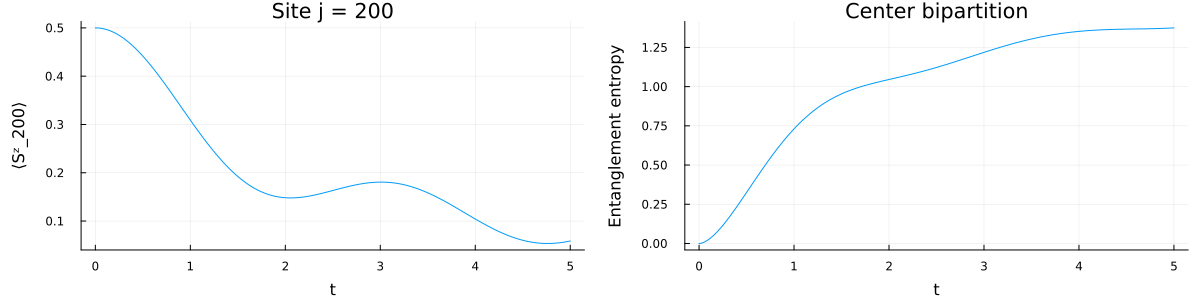

Plots.AnimatedGif("d:\\TFM code\\Tensor Networks Code\\Plots\\spins_evo_magnon.gif")
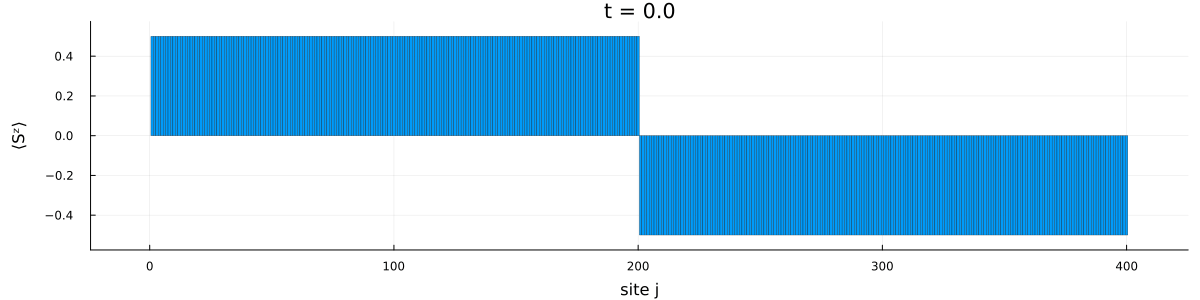

In [4]:
# =============== Initial Non-Mixed State ============== #
N = 400
c = div(N, 2)
s = siteinds("S=1/2", N; conserve_qns=true)
psi = MPS(s, n -> n <= c ? "Up" : "Dn")


# ============== State Evolution ============= #
t = 5.0 # total time of the Evolution
rv   = [1000]
h = [nothing] # h vector
All_evos_pure = Diff_trotter_r(s, psi,  t,  rv; h = h, per = false, cutoff = 1e-8, doprint = false, showprogress = true, normalize_every = 20)

# ============ Plots & Animations ============ #
tau = t/rv[end]
complete_plots(N, t, tau, All_evos_pure)
nothing

In [ ]:
# =============== Initial Non-Mixed State ============== #
N = 400
c = div(N, 2)
s = siteinds("S=1/2", N; conserve_qns=false)
psi = MPS(s, n -> n <= c ? "Up" : "Dn")


# ============== State Evolution ============= #
t = 5.0 # total time of the Evolution
rv   = [1000]
h = [nothing] # h vector
All_evos_pure = Diff_trotter_r(s, psi,  t,  rv; h = h, per = false, cutoff = 1e-8, doprint = false, showprogress = true, normalize_every = 20)

# ============ Plots & Animations ============ #
tau = t/rv[end]
complete_plots(N, t, tau, All_evos_pure)
nothing


$$
\rho_i=\frac{1}{Z_{\mathrm{local}}}
\begin{pmatrix}
e^{\eta_i\mu/2} & 0\\
0 & e^{-\eta_i\mu/2}
\end{pmatrix},

\qquad
Z_{\mathrm{local}}=2\cosh\!\left(\frac{\mu}{2}\right),
$$


$$
\eta_i=
\begin{cases}
+1, & i\le L/2,\\
-1, & i> L/2.
\end{cases}
$$


$$\langle S_{P,i}^z \rangle = \mathrm{Tr}(\rho_i S^z) = \frac{1}{2}\tanh\left(\frac{\eta_i\mu}{2}\right) =
\begin{cases}
+\frac{1}{2}\tanh(\mu/2), & i \le L/2,\\
-\frac{1}{2}\tanh(\mu/2), & i > L/2.
\end{cases}$$

Tr(ρ0) = 0.9999999999999847


MPS evo (r=1000) 100%|███████████████████████████████████| Time: 0:03:35
Computing parameters  43%|██████████████                 |  ETA: 0:00:06┌ Warning: Entropy has a non-negligible imaginary part
│   S = 47.301754249192676 + 4.763859285143896e-7im
└ @ Main d:\TFM code\NoteBook\module\new_att.jl:494
┌ Warning: Entropy has a non-negligible imaginary part
│   S = 47.30177563390642 + 4.949009643304478e-7im
└ @ Main d:\TFM code\NoteBook\module\new_att.jl:494
┌ Warning: Entropy has a non-negligible imaginary part
│   S = 47.30179725645831 + 5.136411727440628e-7im
└ @ Main d:\TFM code\NoteBook\module\new_att.jl:494
┌ Warning: Entropy has a non-negligible imaginary part
│   S = 47.30181912464737 + 5.326139984219053e-7im
└ @ Main d:\TFM code\NoteBook\module\new_att.jl:494
┌ Warning: Entropy has a non-negligible imaginary part
│   S = 47.301841248854565 + 5.517687093883379e-7im
└ @ Main d:\TFM code\NoteBook\module\new_att.jl:494
┌ Warning: Entropy has a non-negligible imaginary part
│   S = 

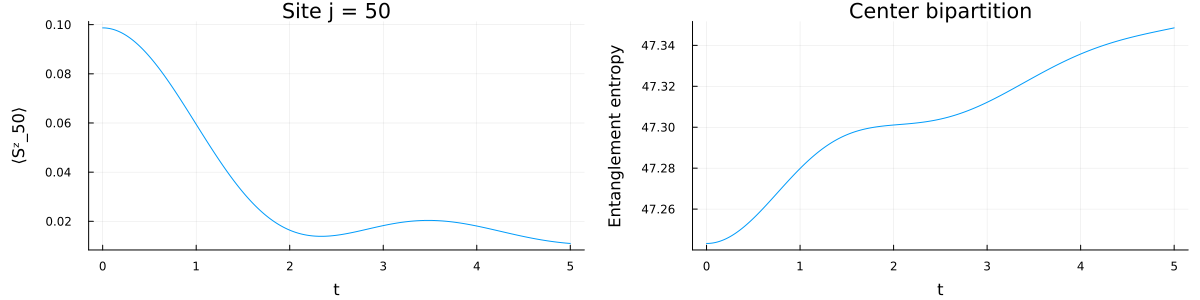

Plots.AnimatedGif("d:\\TFM code\\NoteBook\\Plots\\spins_evo_magnon.gif")
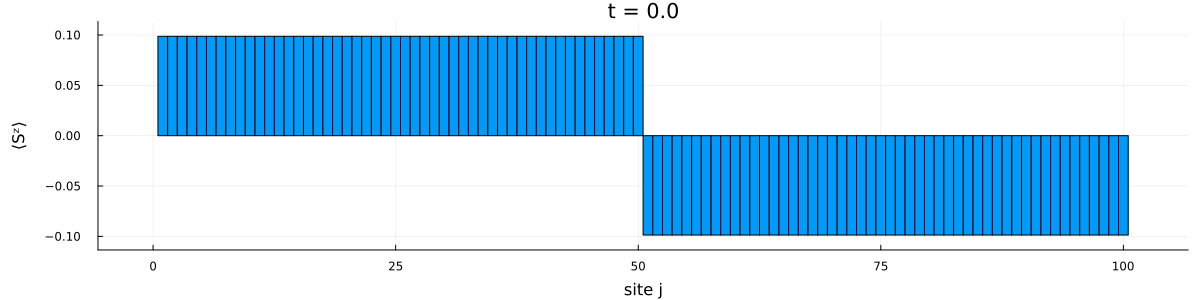

In [ ]:
# =============== Initial Mixed State ============== #
N = 100
μ = 0.5
ρ0, sites = initial_rho_mu(N, μ; normalize=true, conserve_qns=true)
_normalize!(ρ0)

# ============== State Evolution ============= #
t = 5.0 # total time of the Evolution
rv   = [1000]
h = [nothing] # h vector
All_evos_mixed = Diff_trotter_r(sites, ρ0,  t,  rv; h = h, per = false, 
                                cutoff = 1e-8, doprint = true, showprogress = true, 
                                hermitianize = true, normalize_every = 33)

# ============ Plots & Animations ============ #
tau = t/rv[end]
complete_plots(N, t, tau, All_evos_mixed)
nothing

### Hermitianize test

In [5]:
rho, sites = initial_rho_mu(8, 0.7; normalize=true)

println("err before = ", hermiticity_error(rho))

rhoH = hermitianize(rho; cutoff=1e-10, normalize=false)

println("err after  = ", hermiticity_error(rhoH))
println("dist       = ", norm(rhoH - rho))
println("tr(rho)    = ", tr(rho))
println("tr(rhoH)   = ", tr(rhoH))

err before = 0.0
err after  = 0.0
dist       = 7.473417450352271e-17
tr(rho)    = 1.000000000000001
tr(rhoH)   = 1.000000000000001


In [6]:
s = siteinds("S=1/2", 6)

ampo = OpSum()
ampo += 1.0, "S+", 3
rho_nonherm = MPO(ampo, s)

println("err before = ", hermiticity_error(rho_nonherm))

hermitianize!(rho_nonherm; cutoff=1e-12, normalize=false)

println("err after  = ", hermiticity_error(rho_nonherm))
println("tr before  = ", tr(rho_nonherm))
println("tr after   = ", tr(rho_nonherm))

err before = 1.4142135623730956
err after  = 0.0
tr before  = 0.0
tr after   = 0.0


# PKZ

=============== Simulation Parameters ===============
   N      = 400           # Number of sites
   r      = 1000          # Number of Trotter steps
   τ      = 0.005         # Trotter step
   t      = 5             # Total simulation time
   cutoff = 1.0e-08      # Singular value cutoff


State evo (r=1000) 100%|█████████████████████████████████| Time: 0:19:26K
┌ Info: Saved animation to d:\TFM code\Tensor Networks Code\Plots\spins_evo_magnon.gif
└ @ Plots C:\Users\erikp\.julia\packages\Plots\8ZnR3\src\animation.jl:156
GKS: Possible loss of precision in routine SET_WINDOW


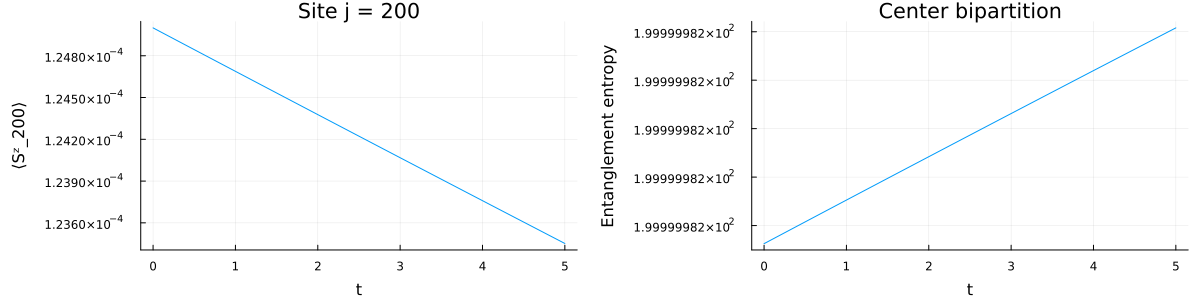

Plots.AnimatedGif("d:\\TFM code\\Tensor Networks Code\\Plots\\spins_evo_magnon.gif")
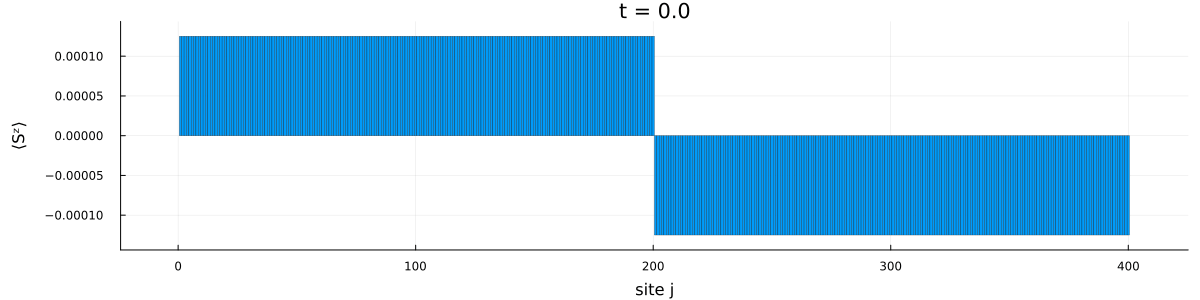

In [ ]:
# =============== Initial Mixed State ============== #
N = 400
μ = 0.0005
ρ0, sites = initial_rho_mu(N, μ; normalize=true, conserve_qns=true)
_normalize!(ρ0)

# ============== State Evolution ============= #
t = 5.0 # total time of the Evolution
rv   = [1000]
h = [nothing] # h vector
All_evos_KPZ = Diff_trotter_r(sites, ρ0,  t,  rv; h = h, per = false, 
                                cutoff = 1e-8, doprint = true, showprogress = true, 
                                hermitianize = true, normalize_every = 33)

# ============ Plots & Animations ============ #
tau = t/rv[end]
complete_plots(N, t, tau, All_evos_KPZ)
nothing